In [1]:
import os
import sys
sys.path.append(os.path.abspath("../../../"))



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from classes.neural_networks.training.train_arima import train_and_evaluate_arima, load_data

In [9]:
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)  # Parâmetros ARIMA (p, d, q)

os.makedirs(model_dir, exist_ok=True)

df = load_data(csv_path)

target = "VALE3"

In [10]:
try:
    arima_model, metrics, predictions = train_and_evaluate_arima(csv_path, target, order, model_dir, version)
    
    print(f"\nMétricas do modelo ARIMA para {target}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
except Exception as e:
    print(f"Erro durante o treinamento: {e}")


2025-06-02 11:49:51,478 - INFO - Carregando dados para VALE3
2025-06-02 11:49:51,603 - INFO - Tamanho do treino: 2869 | Tamanho do teste: 455
c:\Users\mathi\DEV\tcc_cripto\icaro_model\analises-tcc-cripto\main\classes\neural_networks\architectures\arima_model.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.model_fit.forecast(steps=1)[0]
c:\Users\mathi\DEV\tcc_cripto\icaro_model\analises-tcc-cripto\main\classes\neural_networks\architectures\arima_model.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.model_fit.forecast(steps=1)[0]
c:\Users\mathi\DEV\tcc_cripto\icaro_model\analises-tcc-c


Métricas do modelo ARIMA para VALE3:
MSE: 2.2215
RMSE: 1.4905
MAE: 1.1354
R2: 0.9678


In [11]:
# Carregar os valores reais e previstos
test_values = np.load(os.path.join(model_dir, f"{target}_arima_rolling_y_true_v{version}.npy"))
predicted_values = np.load(os.path.join(model_dir, f"{target}_arima_rolling_y_pred_v{version}.npy"))

# Obter as datas corretas
test_series = df[target].dropna()
test_dates = test_series.index[-len(test_values):]

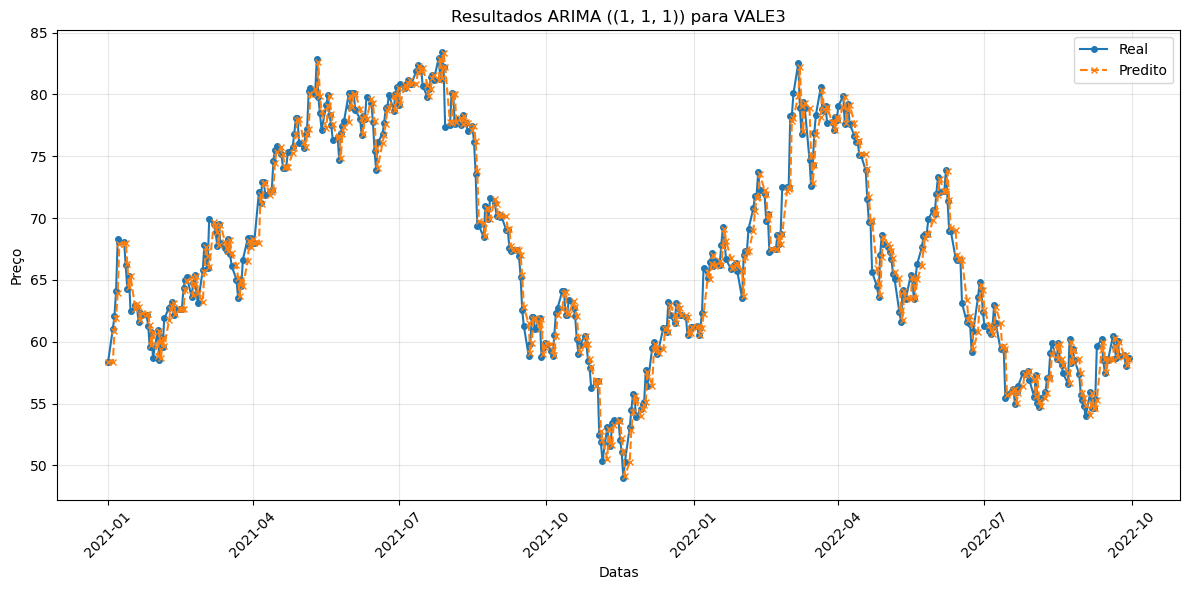

In [12]:
# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(test_dates, test_values, label='Real', marker='o', markersize=4)
plt.plot(test_dates, predicted_values, label='Predito', linestyle='--', marker='x', markersize=4)

plt.title(f"Resultados ARIMA ({order}) para {target}")
plt.xlabel('Datas')
plt.ylabel('Preço')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()